# Problem Setup (Bratu 1D Equation)

**PDE:**
$$\frac{d^2 u}{d x^2} + C e^{u} = 0, x \in (0,1)$$

dengan
$$\Omega = (0,1)$$
Untuk ukuran kolokasi point dengan
$$h = \frac{1}{n}$$

**Loss Residual:**
Andaikan $y_{nn}$ merupakan fungsi neural networks. Sehingga residualnya
$$\frac{d^2 y_{nn}}{d x^2} + C e^{y_{nn}} \approx \frac{d^2 u}{d x^2} + C e^{u} = 0$$

Karena memakai hard constraint dengan $p(x)=x(1-x)$,maka kita tidak memerlukan loss dari bc. Sehingga total dari loss:
$$MSE_{total} = MSE_{pde}$$

# Boundary Conditions
$$u(0) = 0, u(1)=0$$

# Analytic Solution
Melihat dari referensi Shahab et.al (2025)
dengan nilai $C=1$:
$$u(x) = 2 ln (\frac{cosh(\theta)}{cosh(\theta(1-2x))})$$
dimana $\theta$:
$$cosh = \frac{4 \theta}{\sqrt(2C)}$$
Dengan nilai $\theta = 0.379291149762689$

In [1]:
import torch
import torch.autograd as autograd   # computation graph
from torch import Tensor # tensor node in the computation graph
import torch.nn as nn # neural network from torch
import torch.optim as optim # optimizers

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker
from sklearn.model_selection import train_test_split

import numpy as np
import time
import pandas as pd
import scipy.io

torch.set_default_dtype(torch.float)

torch.manual_seed(1234)
np.random.seed(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## NEURAL NETWORKS

In [2]:
# MLP model
class PINN(nn.Module):
  """ set hidden layer with architecture 1-nh-nh-1 """
  def __init__(self, n_hidden=20):
    super(PINN, self).__init__()

    self.net = nn.Sequential(
        nn.Linear(1, n_hidden),
        nn.Tanh(),
        nn.Linear(n_hidden, n_hidden),
        nn.Tanh(),
        # nn.Linear(n_hidden, n_hidden),
        # nn.Tanh(),
        nn.Linear(n_hidden, 1)
        )
  def forward(self,x):
    """
    Forward pass : input shape (batch_size,1) -> output shape
    (batch_size,1) and Hard Contsraints
    """
    nn_out = self.net(x)
    # constraint = (1-x**2)
    constraint =  x * (1 - x)

    return constraint * nn_out

model = PINN(n_hidden=20).to(device)
# Perkecil bobot layer output agar u awal mendekati 0
with torch.no_grad():
    model.net[-1].weight.mul_(0.01)
    model.net[-1].bias.mul_(0.01)

# Automatic Differentiation
def derivative(y,x):
  """
  Compute the derivative of y with respect to x
  """
  return torch.autograd.grad(
      y,x,
      grad_outputs=torch.ones_like(y),
      retain_graph=True,
      create_graph=True
      )[0]

## LOSS RESIDUAL

In [3]:
def physics_loss(model,x,C):
  """
  Compute the loss residual of the PDE
  """
  # F = U_xx + C*exp(U)
  u = model(x)
  u_x = derivative(u, x)
  u_xx = derivative(u_x, x)
  f = u_xx + C*torch.exp(u)
  loss_pde = torch.mean(f**2)
  return loss_pde

## SETTING PROBLEM

In [4]:
C = 1
theta = 0.379291149762689
n_col = 200
h_col = 1 / n_col

# domain x in (0,1), titik interior (hindari tepat 0 dan 1)
x_train = np.linspace(h_col, 1 - h_col, n_col)
x_train = x_train.reshape(-1, 1)
x_train = torch.tensor(x_train, dtype=torch.float32, device=device)
x_train.requires_grad_(True)

print("x_train range:", x_train.min().item(), x_train.max().item())
print("x_train shape:", x_train.shape)

x_train range: 0.004999999888241291 0.9950000047683716
x_train shape: torch.Size([200, 1])


In [5]:
# jacobian for l-bfgs
optimizer = torch.optim.LBFGS(
    model.parameters(),
    max_iter=2000,
    max_eval=1250,
    history_size=50,
    tolerance_grad=1e-10,
    tolerance_change=1e-12,
    line_search_fn="strong_wolfe"
)


def closure():
    """
    Closure ini berperan sebagai 'blok Jacobian':
    - menghitung loss
    - menghitung gradien loss terhadap SEMUA parameter model (Jacobian/gradien)
    - mengembalikan loss ke optimizer
    """
    optimizer.zero_grad()
    loss = physics_loss(model, x_train, C=C)
    loss.backward()
    return loss

# Training dengan log loss di setiap evaluasi closure
loss_log = []

def closure():
    optimizer.zero_grad()
    loss = physics_loss(model, x_train, C=C)
    loss.backward()
    loss_log.append(loss.item())
    return loss

loss_history = []
for epoch in range(1):
    loss = optimizer.step(closure)
    loss_history.append(loss.item())

# Tampilkan setiap iterasi loss
for i, l in enumerate(loss_log):
    print(f"Iter {i+1:4d} | loss: {l:.6e}")

Iter    1 | loss: 1.004343e+00
Iter    2 | loss: 7.148898e-02
Iter    3 | loss: 8.884358e-03
Iter    4 | loss: 1.531898e-03
Iter    5 | loss: 3.322762e-04
Iter    6 | loss: 3.260755e-04
Iter    7 | loss: 2.812493e-04
Iter    8 | loss: 1.414364e-04
Iter    9 | loss: 2.144547e-05
Iter   10 | loss: 2.600444e-06
Iter   11 | loss: 2.139057e-06
Iter   12 | loss: 2.130018e-06
Iter   13 | loss: 2.128315e-06
Iter   14 | loss: 2.120177e-06
Iter   15 | loss: 2.103832e-06
Iter   16 | loss: 2.057445e-06
Iter   17 | loss: 1.948866e-06
Iter   18 | loss: 1.707223e-06
Iter   19 | loss: 1.292788e-06
Iter   20 | loss: 8.159698e-07
Iter   21 | loss: 5.675549e-07
Iter   22 | loss: 5.448215e-07
Iter   23 | loss: 5.433636e-07
Iter   24 | loss: 5.432360e-07
Iter   25 | loss: 5.431978e-07
Iter   26 | loss: 5.429625e-07
Iter   27 | loss: 5.428700e-07
Iter   28 | loss: 5.428332e-07
Iter   29 | loss: 5.425617e-07
Iter   30 | loss: 5.422384e-07
Iter   31 | loss: 5.394713e-07
Iter   32 | loss: 5.227843e-07
Iter   3

In [8]:
x_plot = np.linspace(0, 1, 200).reshape(-1, 1)
x_plot_tensor = torch.tensor(x_plot, dtype=torch.float32, device=device)

with torch.no_grad():
    u_pred = model(x_plot_tensor).numpy()

u_analytic = 2 * np.log(np.cosh(theta) / np.cosh(theta * (1 - 2 * x_plot)))

l2_error = np.linalg.norm(u_pred - u_analytic) / np.linalg.norm(u_analytic)
print(f"L2 relative error: {l2_error:.6e}")

L2 relative error: 9.259733e-07


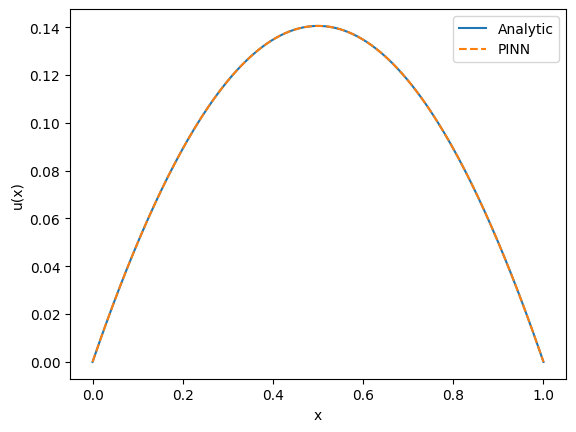

In [9]:

plt.plot(x_plot, u_analytic, label="Analytic")
plt.plot(x_plot, u_pred, '--', label="PINN")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.show()